### MEG Workshop: Intro to Multivariate Methods
Code written by Lina Teichmann, April 2025

___
The main purpose of this notebook is to demonstrate the method and facilite learning. Feel free to make it all nicer by wrapping things in functions and streamlining the code to make it more efficient. 

<span style="color:SteelBlue">**Setup: Import packages & define paths**

In [ ]:
import os
import mne,itertools
import pandas as pd
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as lda
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score,GroupKFold
from scipy.ndimage import convolve1d

userid = os.environ['USER']
bids_dir = f'/data/{userid}/meg_workshop_2025adv/Decoding/bids_dir'
subjid = 'S03'


# helper function to run classification with LDA
def pipeline():
    return Pipeline([('scaler', StandardScaler()), ('clf', lda(solver='eigen', shrinkage=0.01))])

def train_lda(X_train, y_train):
    return pipeline().fit(X_train, y_train)

def test_lda(pipe,X_test,y_test,res_type='acc'):
    if res_type=='acc':
        res = pipe.score(X_test,y_test)
    elif res_type=='pred':
        pred = pipe.predict(X_test)
        res = np.stack([pred,y_test],axis=0)
    return res


In [ ]:
# ### Preprocessing
# from mne_bids import BIDSPath,read_raw_bids

# # 1) raw data is loaded
# # 2) Notch filter and high-pass filter (0.5 Hz)
# # 3) Epoch, create metadata with trial type info and select only meg sensors

# def load_raw(bids_path,run):
#     bids_path.update(run=str(run).zfill(2))
#     raw = read_raw_bids(bids_path=bids_path, verbose=False, extra_params={'system_clock':'ignore'})
#     raw.load_data()
#     return raw

# def filter(raw):
#     raw.notch_filter(np.arange(60, 241, 60), phase='zero-double', fir_design='firwin2')
#     raw.filter(l_freq=0.5,h_freq=None)
#     return raw

# def make_metadata(epochs,events,event_id,subjid,run):
#     df = pd.DataFrame()
#     df['im_class'] = [e.split('_')[0] for e in event_id]
#     df['im_category'] = [e.split('_')[1] for e in event_id]
#     df['im_exemplar'] = [e.split('_')[2] for e in event_id]
#     df['im_number'] = [int(e.split('_')[3].split('.')[0]) for e in event_id]
#     df['participant']=subjid
#     df['run']=int(run)
#     epochs.metadata = df.loc[events[:,2]-1,:]
#     epochs.metadata.reset_index(drop=True,inplace=True)
    
#     return epochs

# def make_epochs(raw,run):
#     events, event_id = mne.events_from_annotations(raw)
#     event_id['target_target_target_01.png'] = event_id.pop('target')

#     epochs = mne.Epochs(raw, events, tmin=-0.1, tmax=0.7, preload=True, baseline=None, 
#                             reject=None , reject_by_annotation=False,event_id=event_id)
#     epochs = make_metadata(epochs,events,event_id,subjid,run)
#     epochs.pick('mag')
#     return epochs

# def concat_epochs(epochs,run_epochs):
#     if epochs:
#         run_epochs.info['dev_head_t'] = epochs.info['dev_head_t']
#         epochs = mne.concatenate_epochs([epochs,run_epochs])
#     else:
#         epochs = run_epochs
#     return epochs

# def run_preproc(bids_root,subjid,n_runs):  

#     bids_path = BIDSPath(root=bids_root, session='1', suffix='meg',extension='.ds', 
#                         subject=subjid,task='VisualAnagrams',run='01', datatype='meg')

#     all_epochs = []
#     for run in range(1,n_runs+1):
#         raw = load_raw(bids_path,run)
#         raw = filter(raw)
#         run_epochs = make_epochs(raw,run)
#         all_epochs = concat_epochs(all_epochs,run_epochs)
        
#     return all_epochs
    
# epochs = run_preproc(bids_dir,subjid,n_runs=8)
# epochs.save(f"{bids_dir}/derivatives/meg/preprocessed/sub-{subjid}_preprocessed-epo.fif",split_naming='bids',overwrite=True)


<span style="color:SteelBlue">**Load epoched data**


In [ ]:
epochs = mne.read_epochs(f"{bids_dir}/derivatives/meg/preprocessed/sub-{subjid}_preprocessed-epo.fif")

# remove target trials (repeated images that required a button press)
epochs = epochs[epochs.metadata['im_class']!='target']

# addng cross-validation index to do a half-way cross validation instead of run-wise (faster)
epochs.metadata['cv_idx']=0
epochs.metadata.loc[epochs.metadata['run']<5,'cv_idx']=1

# plot averaged data
epochs.average().plot()

# display metadata
print(epochs.metadata)

# variables
n_timepoints = epochs._data.shape[2]
n_channels = epochs._data.shape[1]
n_trials = epochs._data.shape[0]

<span style="color:MediumVioletRed">**Challenge 1: Time-resolved category decoding with split-half cross-validation**.

Is there a reliable representations of category (i.e., objects and people) in the MEG data when participants viewed (a) control images and (b) anagram images? 
___
>__Train and test a model to distinguish objects and people__\
>✨ This needs to be done separately for control and anagram trials\
>✨ We need to cross-validate (e.g., split-half) to ensure we are training and testing on independent data\



In [219]:
# initalize empty array to save decoding accucracies
cross_validated_results_all = []

# loop over the image classes
for im_class in ['control','anagram']:
    # select only relevant trials (e.g., controls or anagrams)
    print(f'running analysis for {im_class}')
    selected_epochs = epochs[epochs.metadata['im_class']==im_class]

    # Trainig and testing of the model with cross-validation
    cross_validated_results = []
    for cv in selected_epochs.metadata['cv_idx'].unique():
        training_set = selected_epochs[selected_epochs.metadata['cv_idx']!=cv]
        testing_set = selected_epochs[selected_epochs.metadata['cv_idx']==cv]

        # separate the data from the labels (get x and Y for training and testing set)
        label_encoder = LabelEncoder() # this essentially makes the labels into 1s and 0s
        y_train = label_encoder.fit_transform(training_set.metadata['im_category'])
        y_test = label_encoder.fit_transform(testing_set.metadata['im_category'])
        x_train = training_set._data
        x_test = testing_set._data

        # run classification at every timepoint
        res = []
        for t in tqdm(range(n_timepoints)):
            trained_model = train_lda(x_train[:,:,t], y_train)
            res.append(test_lda(trained_model,x_test[:,:,t],y_test,res_type='acc'))

        # append results from this cross-validation fold
        cross_validated_results.append(res)
    
    # append average performance from all cross-validation folds for the current image class
    cross_validated_results_all.append(np.mean(cross_validated_results,axis=0))



running analysis for anagram


100%|██████████| 961/961 [01:08<00:00, 13.97it/s]


In [ ]:
# # another version doing the same thing as above but making use of more of the sklearn functions
# # this is 20 seconds faster than the more step-by-step version above
# X = epochs._data

# label_encoder = LabelEncoder()
# y = label_encoder.fit_transform(epochs.metadata['im_category'].to_numpy())

# groups = epochs.metadata['cv_idx'].to_numpy()
# group_kfold = GroupKFold(n_splits=len(np.unique(groups)))

# cross_validated_results_all = []
# for im_class in ['control','anagram']:
#     mask = epochs.metadata['im_class']==im_class

#     accuracy = [cross_val_score(pipeline(), X[mask,:,t], y[mask],
#         cv=group_kfold.split(X[mask,:,t], y[mask], groups[mask]),
#         scoring='accuracy'
#     ).mean() for t in range(n_timepoints)]

#     cross_validated_results_all.append(accuracy)


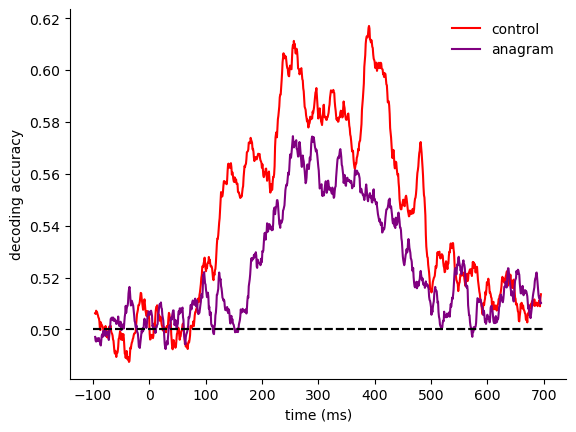

In [228]:
# plotting
colors = ['red','purple']
for i,im_class in enumerate(['control','anagram']):
    toplot = np.array(cross_validated_results_all)[i]
    conv_kernel = 12
    smoothed_data = convolve1d(toplot.reshape(toplot.shape[0]), np.ones(conv_kernel) / conv_kernel, mode='constant',cval=np.nan)

    plt.plot(epochs.times*1000,smoothed_data,label=im_class,color=colors[i])
    plt.plot(epochs.times*1000,epochs.times*0+0.5,'k--')
    plt.xlabel('time (ms)')
    plt.ylabel('decoding accuracy')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.legend(frameon=False)

<span style="color:MediumVioletRed">**Challenge 2: Time-resolved category decoding across stimulus type**.

Does category information from control images generalize to anagrams despite matched low-level features?

___
>__Train a model on control image trials to distinguish objects and people and test on selected anagrams__\
>✨ contrast trials that used the same anagram but presented upright versus inverted (you can select different anagrams below and look how the plot changes)\
>✨ think about what above- and below-chance decoding means in this context\
>✨ come up with an intuitive way to plot the results


In [222]:
# Train the model on control images
label_encoder = LabelEncoder()

# training set: select control stimuli and use label encoder to set y_train to be 0s and 1s instead of im_category. 
training_set = epochs[epochs.metadata['im_class']=='control']
y_train = label_encoder.fit_transform(training_set.metadata['im_category'])
x_train = training_set._data

# train the model
trained_model = [train_lda(x_train[:,:,t], y_train) for t in tqdm(range(x_train.shape[2]))]


100%|██████████| 961/961 [01:15<00:00, 12.78it/s]


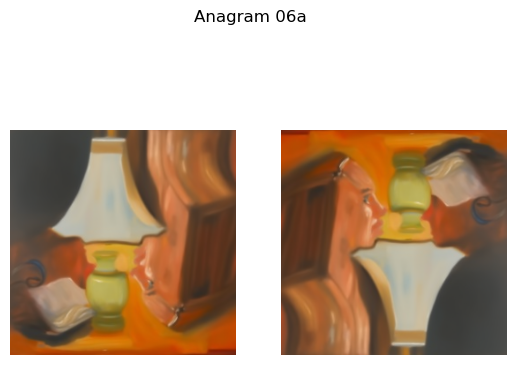

In [223]:
# Test model on selected anagram

# optional: look at which anagram you want to classify (default 6a is a good anagram for this person)
im_num = 6 # 1-12
exemplar = 'a' # a or b
ims_path = []
ims_path.append(f'{bids_dir}/sourcedata/stimuli/anagram_object_{exemplar}_{str(im_num).zfill(2)}.png')
ims_path.append(f'{bids_dir}/sourcedata/stimuli/anagram_person_{exemplar}_{str(im_num).zfill(2)}.png')

fig,axs = plt.subplots(1,2)
for i in range(2):
    im = plt.imread(ims_path[i])
    axs[i].imshow(im)
    axs[i].axis('off')
fig.suptitle(f'Anagram {str(im_num).zfill(2)}{exemplar}')

# Testing set: select anagram and get evoked data
# The anagram is defined by "im_num" and "exemplar"
# The label (y_test) is still im_category.
testing_set = epochs[epochs.metadata['im_class']=='anagram']
x_test = testing_set[(testing_set.metadata['im_number']==im_num)&(testing_set.metadata['im_exemplar']==exemplar)]._data
y_test = label_encoder.fit_transform(testing_set.metadata[(testing_set.metadata['im_number']==im_num)&(testing_set.metadata['im_exemplar']==exemplar)]['im_category'])

# test the model: set res_type='pred' to get the predicitions instead of the accuracy
res = [test_lda(trained_model[t],x_test[:,:,t],y_test,res_type='pred') for t in range(x_train.shape[2])]


# tease apart the results for anagram "object" and anagram "person" [hint: dimension 1 in res captures the true class]
# you can use label_encoder.classes_ to get the class order
true_class_idx_0 = np.array(res)[0,1,:]==0
correct_predictions_class0 = np.array(res)[:,0,true_class_idx_0]==0

true_class_idx_1 = np.array(res)[0,1,:]==1
correct_predictions_class1 = np.array(res)[:,0,true_class_idx_1]==1


Text(-20, -30.0, 'Predicting object')

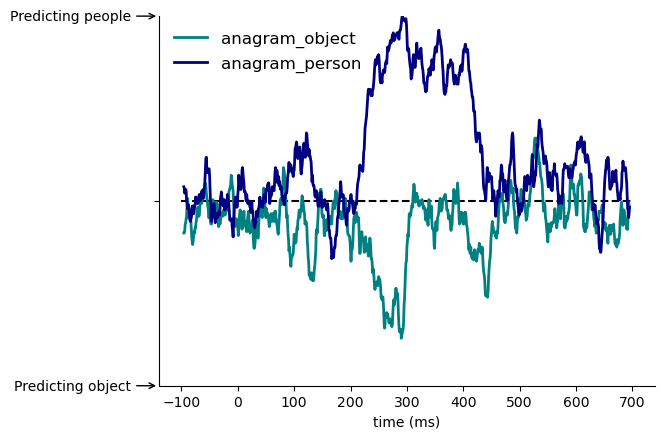

In [227]:
# plot 
fig,ax = plt.subplots()
conv_kernel = 12
ylim = [-30,30]

# swapping the directionality for object decoding and then plotting so that predictions for persons points upwards and for objects downwards
toplot1= np.mean(correct_predictions_class1,axis=1)-0.5
label1 = label_encoder.classes_[1]

toplot0= 1-np.mean(correct_predictions_class0,axis=1)-0.5
label0 = label_encoder.classes_[0]


ax.plot(epochs.times*1000,epochs.times*0,'k--')
for toplot,color,label in zip([toplot0,toplot1],['teal','navy'],[label0,label1]):
    smoothed_data = convolve1d(toplot.reshape(toplot.shape[0]), np.ones(conv_kernel) / conv_kernel, mode='constant',cval=np.nan)
    ax.plot(epochs.times*1000,smoothed_data*100,c=color,lw=2,label=label)

# Customize plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('time (ms)')
ax.legend(fontsize=12,frameon=False)
ax.set_yticks([0])
ax.set_yticklabels([])
ax.set_ylim(ylim)
ymin, ymax = ax.get_ylim()

# Get the limits of the y-axis & add arrows with labels next to the y-axis pointing up and down
ymin, ymax = ax.get_ylim()

ax.annotate('Predicting people', xy=(0,ymax), xytext=(-20, ymax),
            xycoords=('axes fraction', 'data'), textcoords=('offset points', 'data'),
            arrowprops=dict(facecolor='black', arrowstyle='->'),
            horizontalalignment='right', verticalalignment='center')

ax.annotate('Predicting object', xy=(0, ymin), xytext=(-20, ymin),
            xycoords=('axes fraction', 'data'), textcoords=('offset points', 'data'),
            arrowprops=dict(facecolor='black', arrowstyle='->'),
            horizontalalignment='right', verticalalignment='center')


<span style="color:MediumVioletRed">**Bonus content: Single timepoint representational dissimilarity matrix (RDM)**.

Generate a representational dissimilarity matrix (RDM) to summarize how well different image categories (i.e., person versus object) can be decoded within and across image types (i.e., anagrams versus controls).

Note: This problem could be run on the image level (i.e., comparing all 96 images with each other) which is typically what is done -- it just takes a lot longer.

___
>✨Think about what the RDM pattern means.\
>✨Generate a RDM at a different timepoint and see whether the results look as you would expect. 


In [225]:
# select one timepoint of interest (250-300ms is quite good)
t_min = np.where(epochs.times==0.25)[0][0]
t_max = np.where(epochs.times==0.3)[0][0]
X = np.mean(epochs._data[:,:,t_min:t_max],axis=2)

# get the classes/labels for the decoding problem: 
# they are a combination of image class (anagram v control) and image category (object vs person)
rdm_class = epochs.metadata['im_class']+'_'+epochs.metadata['im_category']
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(rdm_class.to_numpy())
classes = np.unique(y)
n_classes = len(classes)

# we are using a sklearn function to run the cross-validation which needs the cross-validation groups to be specified like this [more efficient]
groups = epochs.metadata['run'].to_numpy()
group_kfold = GroupKFold(n_splits=len(np.unique(groups)))

# initalize empty RDM
rdm = np.zeros((n_classes, n_classes))

# iterate over all unique pairs of classes and run the decoding (cross-validated over runs)
for (i, class1), (j, class2) in tqdm(itertools.combinations(enumerate(classes), 2)):
    mask = (y == class1) | (y == class2)
    X_pair = X[mask,:]
    y_pair = y[mask]
    groups_pair = groups[mask]

    accuracy = cross_val_score(pipeline(), X_pair, y_pair,
        cv=group_kfold.split(X_pair, y_pair, groups_pair),
        scoring='accuracy'
    ).mean()

    rdm[i, j] = accuracy
    rdm[j, i] = accuracy

np.fill_diagonal(rdm, np.nan)


6it [00:02,  2.08it/s]


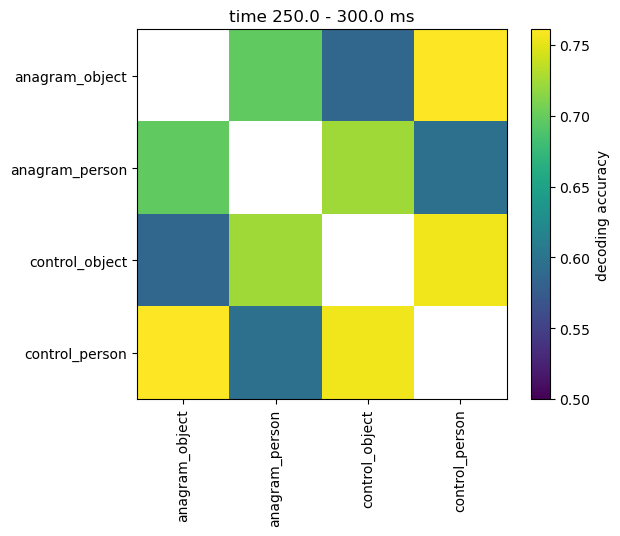

In [226]:
# plot
plt.imshow(rdm,cmap='viridis',vmin=0.5)
plt.xticks(np.arange(n_classes))
plt.yticks(np.arange(n_classes))
plt.gca().set_xticklabels(label_encoder.classes_,rotation=90)
plt.gca().set_yticklabels(label_encoder.classes_)
plt.title(f"time {epochs.times[t_min]*1000} - {epochs.times[t_max]*1000} ms")
plt.colorbar(label='decoding accuracy')
